#Problem Statement

The real estate market is influenced by multiple factors such as property size, number of rooms, location-based amenities, furnishing status, and other housing features.
Accurately estimating house prices is essential for buyers, sellers, and real estate companies to make informed decisions.
However, manually evaluating the impact of multiple variables on house prices is complex and error-prone.

#Objective
To develop a regression-based predictive model that estimates house prices based on various property features using data analysis and machine learning techniques.
The model aims to learn relationships between independent variables and house prices to provide accurate and reliable predictions.


In [1]:
# Import the required libraries
import pandas as pd

In [2]:
# Load and read the dataset
df=pd.read_csv('/content/Housing.csv')

The dataset was successfully loaded and read.

In [3]:
df.head() # Display the first 5 rows of the dataset

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape # Display the dimensions of the dataset

(545, 13)

The dataset contains 545 rows and 13 columns.

In [5]:
df.info() # Display the concise summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Displayed the dataset structure to identify the numerical and categorical features and their datatype.

In [6]:
df.describe() # Display the summary statistics of the dataset

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Displayed the descriptive statistics of the numerical features of the dataset before preprocessing.

In [7]:
# Check for missing values
missing_values=df.isnull().sum().sum()
print(missing_values)

0


No missing values found in the dataset.

In [8]:
# Check for duplicate values
duplicate=df.duplicated().sum()
print(duplicate)

0


No duplicate rows found in the dataset.

In [9]:
# Convert the prices into lakhs
df['price']=df['price']/100000
df['price']=df['price'].round(2)

Converted house prices to lakhs to reduce numeric magnitude and improve numerical stability during regression modelling.

In [10]:
# Rename the columns
df=df.rename(columns={'price':'prices_in_lakhs','area':'area_sqft','mainroad':'main_road','guestroom':'guest_room','hotwaterheating':'hot_water_heating','airconditioning':'air_conditioning','prefarea':'preferred_area','furnishingstatus':'furnishing_status'})
print(df.columns) # Display the names of the columns after renaming

Index(['prices_in_lakhs', 'area_sqft', 'bedrooms', 'bathrooms', 'stories',
       'main_road', 'guest_room', 'basement', 'hot_water_heating',
       'air_conditioning', 'parking', 'preferred_area', 'furnishing_status'],
      dtype='object')


Standardized column names by using underscore(_) to improve readability.

In [11]:
# Convert the datatype of categorical columns
df[['main_road','guest_room','basement','hot_water_heating','air_conditioning','preferred_area','furnishing_status']]=df[['main_road','guest_room','basement','hot_water_heating','air_conditioning','preferred_area','furnishing_status']].astype('category')

Converted categorical variables to the 'category' datatype to clearly distinguish them from the numerical features and prepare them for encoding.

In [12]:
df.info() # Display the concise summary of the dataset after appropriate changes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   prices_in_lakhs    545 non-null    float64 
 1   area_sqft          545 non-null    int64   
 2   bedrooms           545 non-null    int64   
 3   bathrooms          545 non-null    int64   
 4   stories            545 non-null    int64   
 5   main_road          545 non-null    category
 6   guest_room         545 non-null    category
 7   basement           545 non-null    category
 8   hot_water_heating  545 non-null    category
 9   air_conditioning   545 non-null    category
 10  parking            545 non-null    int64   
 11  preferred_area     545 non-null    category
 12  furnishing_status  545 non-null    category
dtypes: category(7), float64(1), int64(5)
memory usage: 30.3 KB


Displayed the dataset structure after preprocessng to verify that numerical and categorical features are correctly represented.

In [13]:
df.describe() # Display the descriptive statistics of the dataset after appropriate changes

,prices_in_lakhs,area_sqft,bedrooms,bathrooms,stories,parking
count,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,47.667284,5150.541284,2.965138,1.286239,1.805505,0.693578
std,18.704392,2170.141023,0.738064,0.502470,0.867492,0.861586
min,17.500000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,34.300000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,43.400000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,57.400000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,133.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


Analyzed the statistical distribution of numerical features after preprocessing to validate data consistency and scale.

In [14]:
from sklearn.preprocessing import OneHotEncoder

df=pd.get_dummies(df,columns=['furnishing_status'], drop_first=True)

Performed one hot encoding on 'furnishing_status' column and displayed the first 5 rows to verify the changes in the dataset.

Changes verified successfully.

In [15]:
# Create a list of binary columns
binary_cols = ['basement', 'hot_water_heating', 'air_conditioning', 'preferred_area', 'main_road', 'guest_room']

# Perform encoding for binary columns
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

Performed encoding for all binary columns.

In [16]:
df.head() # Display the first 5 rows to verify the changes

,prices_in_lakhs,area_sqft,bedrooms,bathrooms,stories,main_road,guest_room,basement,hot_water_heating,air_conditioning,parking,preferred_area,furnishing_status_semi-furnished,furnishing_status_unfurnished
0,133.00,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,122.50,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,122.50,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,122.15,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,114.10,7420,4,1,2,1,1,1,0,1,2,0,False,False


Changes verified successfully.

In [17]:
df.to_csv('preprocessed_housing_data.csv', index=False) #save the preprocessed dataset

Saved the preprocessed dataset successfully.

In [18]:
#import the required libraries
import matplotlib.pyplot as plt
import seaborn as sns

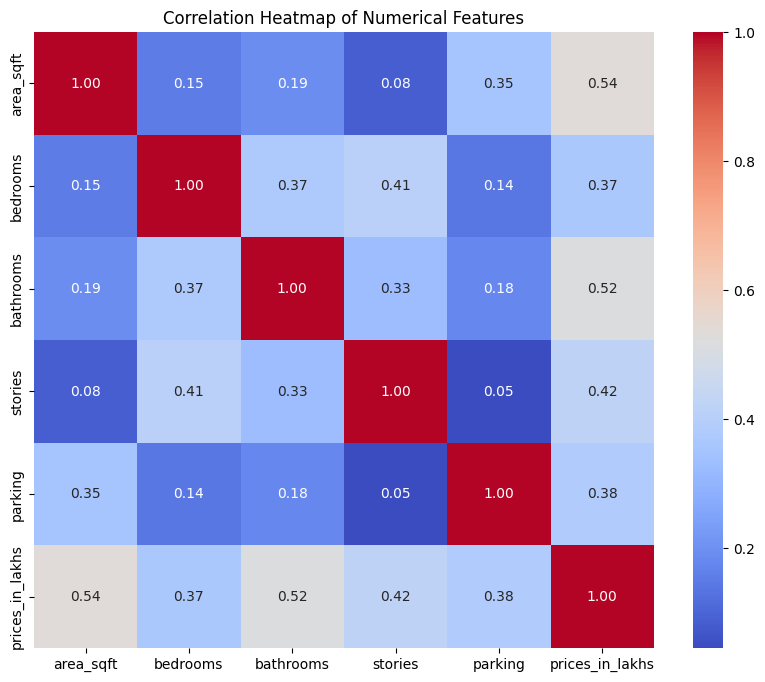

In [19]:
num_features=['area_sqft','bedrooms','bathrooms','stories','parking','prices_in_lakhs']
correlation_matrix= df[num_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Interpretation of Correlation Heatmap**

This heatmap shows the correlation between housing features and price (in lakhs). Correlation values range from 0 to 1, where values closer to 1 indicate a stronger positive relationship.

**Key Observations**

	1.	Price vs Area (0.54) — Strongest relation
	•	House price increases significantly with area (square feet).
	•	Larger houses tend to be more expensive.

	2.	Price vs Bathrooms (0.52) — Strong relation
	•	More bathrooms are associated with higher prices.
	•	Indicates luxury/comfort contributes to price.

	3.	Price vs Stories (0.42) — Moderate relation
	•	Houses with more floors tend to cost more.

	4.	Price vs Parking (0.38) — Moderate relation
	•	Availability of parking positively affects price.

	5.	Price vs Bedrooms (0.37) — Moderate relation
	•	Bedrooms influence price, but less than area and bathrooms.

**Relationships Among Features**

	•	Bedrooms & Stories (0.41): Larger homes tend to have more floors.
	•	Bedrooms & Bathrooms (0.37): More bedrooms usually mean more bathrooms.
	•	Area & Parking (0.35): Bigger homes tend to have parking space.

**Weak Relationships**

	•	Stories & Parking (0.05) show almost no relation.

**Overall Insight**

Area, bathrooms, and number of stories are the most influential features for price prediction. Bedrooms and parking contribute but less strongly.

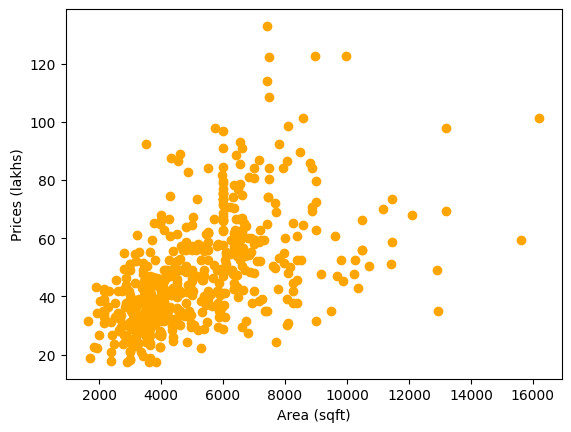

In [20]:
x=df['area_sqft']
y=df['prices_in_lakhs']

plt.scatter(x,y,color='orange')
plt.xlabel('Area (sqft)')
plt.ylabel('Prices (lakhs)')
plt.show()

**Interpretation of Area vs Price Scatter Plot**

This scatter plot shows the relationship between house area (in square feet) and price (in lakhs).

**Key Observations**

	1.	Positive Relationship
	•	As area increases, the price generally increases.
	•	This confirms that larger houses usually cost more.

	2.	Moderate Correlation
	•	Points trend upward, but are not tightly packed.
	•	This means area affects price, but other factors also influence pricing.

	3.	High Density Region
	•	Most houses lie between 2000–6000 sqft and 20–60 lakhs.
	•	Indicates common market range.

	4.	Price Variation for Same Area
	•	Houses with similar area have different prices.
	•	Suggests influence of other factors like location, bathrooms, parking, etc.

	5.	Outliers
	•	A few very large houses (>12000 sqft) with both moderate and very high prices.
	•	These may be luxury or location-dependent properties.

**Overall Insight**

Area is an important factor in determining house price, but it alone cannot fully explain price variation.


In [21]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return outliers, lower_bound, upper_bound

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    outliers, lb, ub = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

prices_in_lakhs: 15 outliers
area_sqft: 12 outliers
bedrooms: 12 outliers
bathrooms: 1 outliers
stories: 41 outliers
parking: 12 outliers


In [22]:
# Create a list of all features affecting the target
features=[
    'area_sqft',
    'basement',
    'hot_water_heating',
    'air_conditioning',
    'parking',
    'preferred_area',
    'bedrooms',
    'bathrooms',
    'stories',
    'main_road',
    'guest_room',
    'furnishing_status_semi-furnished',
    'furnishing_status_unfurnished',
    ]

target='prices_in_lakhs' # target variable

x=df[features]
y=df[target]

The above code selects the relevant input features abd defines the target variable for the housing price prediction problem. The data is separated into independent and dependent variables to prepare it for applying Linear Regression in the further steps.

In [23]:
# Import the required features
from sklearn.model_selection import train_test_split

# Perform train-test split first (using the original 'x' and 'y')
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.8, test_size=0.2, random_state=42
)

The dataset has been split into training and testing sets using the train_test_split function.

In [24]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression Model
lr = LinearRegression()

# Train the model using training data
lr.fit(x_train, y_train)

LinearRegression()

The model has been trained for Linear Regression task.

The model assumes a linear relationship between the input features and house prices. It also assumes that the observations are independent, the errors have constant variance (homoscedasticity), and the residuals are normally distributed. Additionally, the model assumes there is no strong multicollinearity among the independent variables.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the required metrics
def evaluate(model, name):
    y_pred = model.predict(x_test)
    mae = round(mean_absolute_error(y_test, y_pred), 2)
    mse= round(mean_squared_error(y_test, y_pred), 2)
    rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
    r2 = round(model.score(x_test, y_test), 2)

# Display the required metrics
    print(f"\n{name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

evaluate(lr, "Linear Regression")


Linear Regression
MAE : 9.7
MSE : 175.43
RMSE: 13.25
R²  : 0.65


The performance of the Linear Regression model was evaluated using MAE, MSE, RMSE, and R² score. The MAE value indicates that, on average, the model's predicted house prices differ from the actual prices by about 9.7 lakhs, which is reasonable for real-estate data. The RMSE being higher than MAE suggests that some larger prediction errors are present, which is common in housing datasets due to high-value properties. The R² score of about 0.65 shows that the model explains around 65% of the variation in house prices, indicating a moderately good fit. Overall, the model provides a reliable baseline for predicting housing prices using the selected features.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the required metrics
def evaluate(model, name):
    y_pred = model.predict(x_train)
    mae = round(mean_absolute_error(y_train, y_pred), 2)
    mse= round(mean_squared_error(y_train, y_pred), 2)
    rmse = round(np.sqrt(mean_squared_error(y_train, y_pred)), 2)
    r2 = round(model.score(x_train, y_train), 2)

# Display the required metrics
    print(f"\n{name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2)

evaluate(lr, "Linear Regression")


Linear Regression
MAE : 7.19
MSE : 96.84
RMSE: 9.84
R²  : 0.69


**Model Evaluation and Interpretation (Training Data Results)**

The Linear Regression model was evaluated using the training dataset with standard regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R² score).

The model achieved a Mean Absolute Error (MAE) of 7.19, indicating that, on average, predictions differ from actual values by approximately 7 units in the training data. The Mean Squared Error (MSE) is 96.84, which measures the average squared difference between predicted and actual values, penalizing larger errors more strongly. The Root Mean Squared Error (RMSE) of 9.84 represents the typical prediction error magnitude in the original unit of the target variable.

The R² score of 0.69 indicates that approximately 69% of the variance in the target variable is explained by the model on the training dataset. This suggests that the model has learned the underlying relationships reasonably well.

However, since these metrics are computed on training data, they reflect how well the model fits the data it was trained on rather than its performance on unseen data. Therefore, evaluation on a separate test dataset is necessary to assess the model’s generalization capability.

In [27]:
sample = {
    "area_sqft": 8960,
    "basement": 'no',
    "hot_water_heating": 'no',
    "air_conditioning": 'yes',
    "parking": 3,
    "preferred_area": 'no',
    "furnishing_status_unfurnished":0,
    "furnishing_status_semi-furnished":0,
    "bedrooms": 4,
    "bathrooms": 4,
    "stories": 4,
    "main_road": 'yes',
    "guest_room": 'no',
}
import numpy as np
import pandas as pd

input_sample = pd.DataFrame([sample])

# Binary columns were mapped to 0/1 during data preparation for df
# Apply the same mapping to the sample input
binary_cols_for_sample = ['basement', 'hot_water_heating', 'air_conditioning', 'preferred_area', 'main_road', 'guest_room']
for col in binary_cols_for_sample:
    if col in input_sample.columns:
        input_sample[col] = input_sample[col].map({'yes': 1, 'no': 0})

# Ensure the order of columns in input_sample matches the features used for training
# The 'features' list is defined in an earlier cell and was used to create 'x' (and thus 'x_train').
input_sample = input_sample[features]

prediction = lr.predict(input_sample)

print("Predicted Price:", round(prediction[0],2),'Lakhs')

Predicted Price: 105.23 Lakhs


A sample house was created using realistic property features to test the trained model. The same preprocessing and feature ordering used during training were applied to the input. The model predicted a house price of approximately 105.23 lakhs, showing that it can estimate prices for new properties.

In [28]:
#Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train.to_numpy())
x_test = scaler.transform(x_test.to_numpy())

Applied standardization successfully.

In [29]:
#Implement Ridge Regression
from sklearn.linear_model import Ridge

ridge=Ridge(alpha=1.0)
ridge.fit(x_train,y_train)

Ridge()

Ridge Regression has been implemented successfully.

In [30]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the required metrics

def evaluate(model, name):
  y_pred = model.predict(x_train)
  mae = round(mean_absolute_error(y_train, y_pred), 2)
  mse= round(mean_squared_error(y_train, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_train, y_pred)), 2)
  r2 = round(r2_score(y_train,y_pred), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(ridge, "Ridge Regression")


Ridge Regression
MAE : 7.19
MSE : 96.84
RMSE: 9.84
R²  : 0.69


The Ridge Regression model demonstrates moderate predictive performance, with an R² value of 0.69 indicating that it explains about 69% of the variance in house prices. The Mean Absolute Error (MAE) of 7.19 suggests that, on average, the model’s predictions deviate from actual values by around 7 units, while the Root Mean Squared Error (RMSE) of 9.84 indicates slightly higher typical error due to the presence of some larger deviations. The Mean Squared Error (MSE) of 96.84 further reflects the impact of these larger errors. Overall, the model captures the general trend in the data reasonably well but still has scope for improvement in terms of prediction accuracy.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the required metrics

def evaluate(model, name):
  y_pred = model.predict(x_test)
  mae = round(mean_absolute_error(y_test, y_pred), 2)
  mse= round(mean_squared_error(y_test, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
  r2 = round(r2_score(y_test,y_pred), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(ridge, "Ridge Regression")


Ridge Regression
MAE : 9.7
MSE : 175.48
RMSE: 13.25
R²  : 0.65


The Ridge Regression model shows moderate performance on the test data, with an R² value of 0.65 indicating that it explains about 65% of the variance in house prices. The Mean Absolute Error (MAE) of 9.7 suggests that the model’s predictions deviate from actual values by nearly 10 units on average, while the Root Mean Squared Error (RMSE) of 13.25 indicates the presence of some larger prediction errors. The Mean Squared Error (MSE) of 175.48 further highlights the impact of these larger deviations. Compared to training performance, the slight drop in R² and increase in errors suggest minor overfitting, but overall, the model generalizes reasonably well with scope for further improvement.

In [32]:
sample = {
    "area_sqft": 8960,
    "basement": 'no',
    "hot_water_heating": 'no',
    "air_conditioning": 'yes',
    "parking": 3,
    "preferred_area": 'no',
    "furnishing_status_unfurnished":0,
    "furnishing_status_semi-furnished":0,
    "bedrooms": 4,
    "bathrooms": 4,
    "stories": 4,
    "main_road": 'yes',
    "guest_room": 'no',
}
import numpy as np
import pandas as pd

input_sample = pd.DataFrame([sample])

# Binary columns were mapped to 0/1 during data preparation for df
# Apply the same mapping to the sample input
binary_cols_for_sample = ['basement', 'hot_water_heating', 'air_conditioning', 'preferred_area', 'main_road', 'guest_room']
for col in binary_cols_for_sample:
    if col in input_sample.columns:
        input_sample[col] = input_sample[col].map({'yes': 1, 'no': 0})

# Ensure the order of columns in input_sample matches the features used for training
input_sample = input_sample[features]

# Scale the input sample using the same scaler fitted on the training data
input_sample_scaled = scaler.transform(input_sample.to_numpy())

# Prediction
print("Predicted Price:", round(ridge.predict(input_sample_scaled)[0],2),'Lakhs')

Predicted Price: 105.15 Lakhs


The Ridge Regression model predicts the house price to be approximately 105.15 lakhs for the given input features, indicating a relatively higher valuation compared to other models. This high price is mainly influenced by the large area (8960 sqft), multiple bedrooms and bathrooms, multiple stories, and amenities such as air conditioning and parking, along with the advantage of being located on a main road. Although some features like basement, hot water heating, preferred area, and guest room are absent, the strong structural attributes and key facilities significantly drive up the predicted price. Overall, Ridge tends to give a slightly higher estimate, suggesting it captures the influence of these features more strongly.

In [33]:
#Implement Lasso Regression
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0)
lasso.fit(x_train,y_train)

Lasso()

Lasso Regression has been implemented successfully.

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the required metrics

def evaluate(model, name):
  y_pred = model.predict(x_train)
  mae = round(mean_absolute_error(y_train, y_pred), 2)
  mse= round(mean_squared_error(y_train, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_train, y_pred)), 2)
  r2 = round(model.score(x_train, y_train), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(lasso, "Lasso Regression")


Lasso Regression
MAE : 7.26
MSE : 102.8
RMSE: 10.14
R²  : 0.67


The Lasso Regression model shows moderate performance, with an R² value of 0.67 indicating that it explains about 67% of the variance in house prices. The Mean Absolute Error (MAE) of 7.26 suggests that the model’s predictions deviate from actual values by around 7 units on average, while the Root Mean Squared Error (RMSE) of 10.14 indicates the presence of some larger prediction errors. The Mean Squared Error (MSE) of 102.8 further reflects the impact of these deviations. Overall, the model performs reasonably well and slightly better than Ridge Regression in terms of error metrics, but there is still room for improvement in prediction accuracy.

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the required metrics

def evaluate(model, name):
  y_pred = model.predict(x_test)
  mae = round(mean_absolute_error(y_test, y_pred), 2)
  mse= round(mean_squared_error(y_test, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
  r2 = round(model.score(x_test, y_test), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(lasso, "Lasso Regression")


Lasso Regression
MAE : 10.22
MSE : 198.16
RMSE: 14.08
R²  : 0.61


The Lasso Regression model shows moderate performance, with an R² value of 0.67 indicating that it explains about 67% of the variance in house prices. The Mean Absolute Error (MAE) of 7.26 suggests that the model’s predictions deviate from actual values by around 7 units on average, while the Root Mean Squared Error (RMSE) of 10.14 indicates the presence of some larger prediction errors. The Mean Squared Error (MSE) of 102.8 further reflects the impact of these deviations. Overall, the model performs reasonably well and slightly better than Ridge Regression in terms of error metrics, but there is still room for improvement in prediction accuracy.

In [36]:
sample = {
    "area_sqft": 8960,
    "basement": 'no',
    "hot_water_heating": 'no',
    "air_conditioning": 'yes',
    "parking": 3,
    "preferred_area": 'no',
    "furnishing_status_unfurnished":0,
    "furnishing_status_semi-furnished":0,
    "bedrooms": 4,
    "bathrooms": 4,
    "stories": 4,
    "main_road": 'yes',
    "guest_room": 'no',
}
import numpy as np
import pandas as pd

input_sample = pd.DataFrame([sample])

# Binary columns were mapped to 0/1 during data preparation for df
# Apply the same mapping to the sample input
binary_cols_for_sample = ['basement', 'hot_water_heating', 'air_conditioning', 'preferred_area', 'main_road', 'guest_room']
for col in binary_cols_for_sample:
    if col in input_sample.columns:
        input_sample[col] = input_sample[col].map({'yes': 1, 'no': 0})

# Ensure the order of columns in input_sample matches the features used for training
input_sample = input_sample[features]

# Scale the input sample using the same scaler fitted on the training data
input_sample_scaled = scaler.transform(input_sample.to_numpy())

# Prediction
print("Predicted Price:", round(lasso.predict(input_sample_scaled)[0],2),'Lakhs')

Predicted Price: 99.74 Lakhs


The Lasso Regression model predicts the house price to be approximately 99.74 lakhs for the given input features, indicating a high property value driven by factors such as large area (8960 sqft), multiple bedrooms and bathrooms, multiple stories, and amenities like air conditioning and parking. The presence of a main road further enhances the value, while the absence of features like basement, hot water heating, preferred area, and guest room slightly moderates the price. Overall, the prediction suggests that structural features and key amenities play a significant role in determining house prices in the model.

In [37]:
#Implement Elastic Net
from sklearn.linear_model import ElasticNet

enet=ElasticNet(alpha=1.0,l1_ratio=0.5,random_state=42)
enet.fit(x_train, y_train)

ElasticNet(random_state=42)

Elastic Net has been implemented successfully.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, name):
  y_pred = model.predict(x_test)
  mae = round(mean_absolute_error(y_test, y_pred), 2)
  mse= round(mean_squared_error(y_test, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
  r2 = round(model.score(x_test, y_test), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(enet, "Elastic Net")


Elastic Net
MAE : 10.42
MSE : 212.14
RMSE: 14.57
R²  : 0.58


The Elastic Net model shows comparatively weaker performance on the test data, with an R² value of 0.58 indicating that it explains about 58% of the variance in house prices. The Mean Absolute Error (MAE) of 10.42 suggests that predictions deviate from actual values by over 10 units on average, while the Root Mean Squared Error (RMSE) of 14.57 indicates the presence of significant larger errors. The Mean Squared Error (MSE) of 212.14 further reflects the impact of these deviations. Overall, the model underperforms compared to Ridge and Lasso, indicating that it is less effective in capturing the underlying patterns in the data and may require better tuning or feature engineering.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, name):
  y_pred = model.predict(x_train)
  mae = round(mean_absolute_error(y_train, y_pred), 2)
  mse= round(mean_squared_error(y_train, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_train, y_pred)), 2)
  r2 = round(r2_score(y_train, y_pred), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(enet, "Elastic Net")


Elastic Net
MAE : 7.5
MSE : 110.62
RMSE: 10.52
R²  : 0.64


The Elastic Net model shows moderate performance on the training data, with an R² value of 0.64 indicating that it explains about 64% of the variance in house prices. The Mean Absolute Error (MAE) of 7.5 suggests that predictions deviate from actual values by around 7–8 units on average, while the Root Mean Squared Error (RMSE) of 10.52 indicates the presence of some larger errors. The Mean Squared Error (MSE) of 110.62 further reflects the impact of these deviations. Overall, the model captures the general trend reasonably well but is slightly less effective compared to Ridge and Lasso on training data, indicating moderate fit with scope for improvement.

In [40]:
sample = {
    "area_sqft": 8960,
    "basement": 'no',
    "hot_water_heating": 'no',
    "air_conditioning": 'yes',
    "parking": 3,
    "preferred_area": 'no',
    "furnishing_status_unfurnished":0,
    "furnishing_status_semi-furnished":0,
    "bedrooms": 4,
    "bathrooms": 4,
    "stories": 4,
    "main_road": 'yes',
    "guest_room": 'no',
}
import numpy as np
import pandas as pd

input_sample = pd.DataFrame([sample])

# Binary columns were mapped to 0/1 during data preparation for df
# Apply the same mapping to the sample input
binary_cols_for_sample = ['basement', 'hot_water_heating', 'air_conditioning', 'preferred_area', 'main_road', 'guest_room']
for col in binary_cols_for_sample:
    if col in input_sample.columns:
        input_sample[col] = input_sample[col].map({'yes': 1, 'no': 0})

# Ensure the order of columns in input_sample matches the features used for training
input_sample = input_sample[features]

# Scale the input sample using the same scaler fitted on the training data
# Convert the DataFrame to a NumPy array to ensure consistency with how the scaler was fitted
input_sample_scaled = scaler.transform(input_sample.to_numpy())

# Prediction
print("Predicted Price:", round(enet.predict(input_sample_scaled)[0],2),'Lakhs')

Predicted Price: 90.25 Lakhs


The Elastic Net model predicts the house price to be 90.25 lakhs for the given input features, indicating that a property with large area (8960 sqft), multiple bedrooms and bathrooms (4 each), 4 stories, air conditioning, parking for 3 vehicles, and location on a main road is valued relatively high. The absence of features like basement, hot water heating, preferred area, and guest room slightly moderates the price, but the strong influence of size, amenities, and infrastructure leads to an overall high valuation. This prediction aligns with the model’s learned patterns, where structural features and key amenities significantly impact house prices.

In [41]:
# Create a list of all features affecting the target
features=[
    'area_sqft',
    'basement',
    'hot_water_heating',
    'air_conditioning',
    'parking',
    'preferred_area',
    'bedrooms',
    'bathrooms',
    'stories',
    'main_road',
    'guest_room',
    'furnishing_status_semi-furnished',
    'furnishing_status_unfurnished',
    ]

target='prices_in_lakhs' # target variable

x=df[features]
y=df[target]

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200,300,400,500],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}


The GridSearchCV results show that the best Random Forest parameters include 500 trees, max depth of 20, and constraints like minimum samples split (5) and leaf (2), which balance model complexity and prevent overfitting. Overall, this tuned model is expected to give better and more reliable predictions than the default configuration.

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor(n_estimators=500,random_state=42,max_depth= 20, max_features='sqrt', min_samples_leaf= 2, min_samples_split= 5)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=500, random_state=42)

Random Forest has been implemented successfully.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, name):
  y_pred = model.predict(x_test)
  mae = round(mean_absolute_error(y_test, y_pred), 2)
  mse= round(mean_squared_error(y_test, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
  r2 = round(r2_score(y_test,y_pred), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(rf, "Random Forest")


Random Forest
MAE : 10.4
MSE : 198.72
RMSE: 14.1
R²  : 0.61


The Random Forest model demonstrates moderate predictive performance, with an R² value of 0.61 indicating that it explains about 61% of the variance in house prices. The Mean Absolute Error (MAE) of 10.4 suggests that predictions deviate from actual values by around 10 units on average, while the Root Mean Squared Error (RMSE) of 14.1 indicates the presence of some larger errors. The Mean Squared Error (MSE) of 198.72 further reflects the impact of these deviations. Overall, despite hyperparameter tuning, the model does not outperform simpler models significantly and shows scope for improvement in capturing the underlying patterns more effectively.

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the required metrics

def evaluate(model, name):
  y_pred = model.predict(x_train)
  mae = round(mean_absolute_error(y_train, y_pred), 2)
  mse= round(mean_squared_error(y_train, y_pred), 2)
  rmse = round(np.sqrt(mean_squared_error(y_train, y_pred)), 2)
  r2 = round(r2_score(y_train,y_pred), 2)

# Display the required metrics
  print(f"\n{name}")
  print("MAE :", mae)
  print("MSE :", mse)
  print("RMSE:", rmse)
  print("R²  :", r2)

evaluate(rf, "Random Forest")


Random Forest
MAE : 5.25
MSE : 55.15
RMSE: 7.43
R²  : 0.82


The Random Forest model shows strong performance on the training data, with an R² value of 0.82 indicating that it explains about 82% of the variance in house prices. The Mean Absolute Error (MAE) of 5.25 suggests that predictions are quite close to actual values on average, while the Root Mean Squared Error (RMSE) of 7.43 indicates relatively low prediction error with fewer large deviations. The Mean Squared Error (MSE) of 55.15 further confirms the model’s good fit. Overall, the model performs very well on training data, but such high accuracy may also indicate a possibility of overfitting, and its performance on test data should be considered for a complete evaluation.

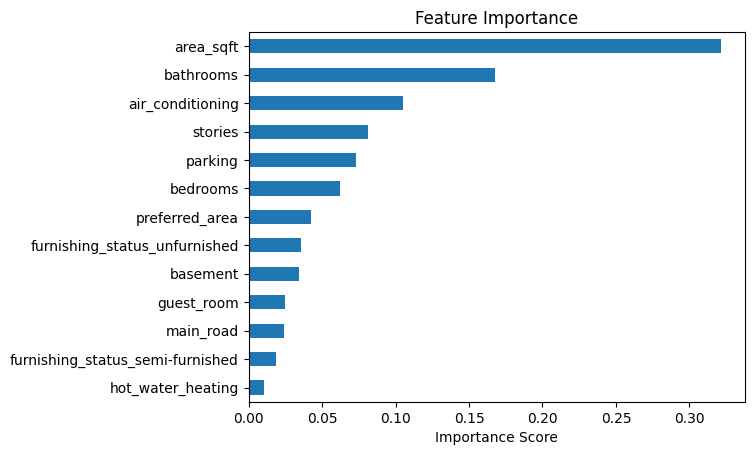

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values(ascending=True).plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

**Interpretation of Feature Importance Plot**

The feature importance plot shows how much each feature contributes to predicting house prices in the model. Higher importance scores mean the feature has a stronger influence on predictions.

**Key Observations**

	1.	Area (sqft) — Most Important Feature
	•	Area has the highest importance score.
	•	Indicates that house size is the primary factor affecting price.

	2.	Bathrooms — Second Most Important
	•	Number of bathrooms strongly impacts price.
	•	More bathrooms often indicate better amenities and higher value.

	3.	Air Conditioning
	•	Presence of air conditioning significantly affects pricing.
	•	Shows comfort features influence house value.

	4.	Stories and Parking
	•	Number of floors and parking availability moderately affect prices.

	5.	Bedrooms
	•	Bedrooms influence price but less than area and bathrooms, since area already captures much of house size.

	6.	Location and Amenities
	•	Features like preferred area, basement, guest room, and main road access have moderate but smaller contributions.

	7.	Furnishing Status & Hot Water Heating
	•	These have relatively low importance, indicating limited impact compared to structural features.

**Overall Insight**

House size and core structural features dominate price prediction, while additional amenities and furnishing contribute less.


In [47]:
sample = {
    "area_sqft": 8960,
    "basement": 'no',
    "hot_water_heating": 'no',
    "air_conditioning": 'yes',
    "parking": 3,
    "preferred_area": 'no',
    "furnishing_status_unfurnished":0,
    "furnishing_status_semi-furnished":0,
    "bedrooms": 4,
    "bathrooms": 4,
    "stories": 4,
    "main_road": 'yes',
    "guest_room": 'no',
}
import numpy as np
import pandas as pd

input_sample = pd.DataFrame([sample])

# Binary columns were mapped to 0/1 during data preparation for df
# Apply the same mapping to the sample input
binary_cols_for_sample = ['basement', 'hot_water_heating', 'air_conditioning', 'preferred_area', 'main_road', 'guest_room']
for col in binary_cols_for_sample:
    if col in input_sample.columns:
        input_sample[col] = input_sample[col].map({'yes': 1, 'no': 0})

# Ensure the order of columns in input_sample matches the features used for training
input_sample = input_sample[features]

# Scale the input sample using the same scaler fitted on the training data
input_sample_scaled = scaler.transform(input_sample.to_numpy())

# Prediction
print("Predicted Price:", round(rf.predict(input_sample_scaled)[0],2),'Lakhs')

Predicted Price: 91.75 Lakhs


The Random Forest model predicts the house price to be 91.75 lakhs for the given input features, indicating a high property value driven by factors such as large area (8960 sqft), multiple bedrooms and bathrooms, multiple stories, air conditioning, and availability of parking. The presence of a main road further adds to the value, while the absence of features like basement, hot water heating, preferred area, and guest room slightly moderates the price. Overall, the prediction reflects that structural features and key amenities have a strong influence on house pricing in the model.

**Conclusion and Model Comparison**

In this project, multiple regression models including Linear Regression, Ridge, Lasso, Elastic Net, and Random Forest were implemented to predict house prices. The models were evaluated using MAE, MSE, RMSE, and R² score on both training and test data.

Linear Regression achieved a good performance with an R² of around 0.69 on training data and 0.65 on test data, showing decent generalization. Ridge and Lasso Regression performed similarly, slightly improving stability due to regularization, with comparable error values and consistent predictions. Elastic Net showed moderate performance but did not outperform Ridge or Lasso. Random Forest achieved very high accuracy on training data (R² ≈ 0.82) but dropped significantly on test data (R² ≈ 0.61), indicating overfitting.

In terms of predictions, all models produced similar price estimates (approximately 90–105 lakhs), confirming that key features such as area, number of bedrooms/bathrooms, and amenities like air conditioning and parking strongly influence house prices. Overall, Linear Regression, Ridge, and Lasso are the most reliable models for this dataset due to their better generalization, while Random Forest requires further tuning to reduce overfitting.